<a href="https://colab.research.google.com/github/nabielyr/Tech-Layoffs-Trend-Analysis/blob/main/Tech_Layoffs_Trend_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Tren Pemutusan Hubungan Kerja (PHK) Industri Teknologi 2020-2025

**Dataset:** https://www.kaggle.com/datasets/ulrikeherold/tech-layoffs-2020-2024

## 1. Import Libraries

Pada tahap ini kita melakukan import semua library yang dibutuhkan untuk analisis data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
print('Libraries berhasil diimport!')

Libraries berhasil diimport!


Library yang digunakan:
1. **Pandas** – manipulasi dan analisis data tabular
2. **NumPy** – operasi numerik
3. **Matplotlib** – visualisasi dasar
4. **Seaborn** – visualisasi statistik yang lebih rapi
5. **Warnings** – menyembunyikan warning yang tidak perlu

## 2. Load Dataset

Dataset dimuat dari Google Drive. Pastikan file CSV sudah diupload ke Drive terlebih dahulu.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/SMT-4/tech_layoffs_til_2025.csv'
df = pd.read_csv(file_path)

print(f'Dataset berhasil dimuat!')
print(f'Jumlah baris   : {df.shape[0]}')
print(f'Jumlah kolom   : {df.shape[1]}')

Dataset berhasil dimuat!
Jumlah baris   : 2412
Jumlah kolom   : 18


## 3. Inspeksi Dataset

Kita lakukan inspeksi awal untuk memahami struktur, tipe data, dan kondisi dataset sebelum analisis lebih lanjut.

In [ ]:
# Lihat 5 baris pertama
print('=== 5 Baris Pertama Dataset ===')
df.head()

=== 5 Baris Pertama Dataset ===


,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude
0,1,Tamara Mellon,Los Angeles,other,California,USA,North America,20.0,2020-03-12,40.0,50.0,30.0,Retail,Series C,90.0,2020,34.053691,-118.242766
1,2,HopSkipDrive,Los Angeles,other,California,USA,North America,8.0,2020-03-13,10.0,80.0,72.0,Transportation,Unknown,45.0,2020,34.053691,-118.242766
2,3,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,8.0,2.0,Consumer,Seed,1.0,2020,37.779259,-122.419329
3,4,Help.com,Austin,other,Texas,USA,North America,16.0,2020-03-16,100.0,16.0,0.0,Support,Seed,6.0,2020,30.271129,-97.743700
4,5,Inspirato,Denver,other,Colorado,USA,North America,130.0,2020-03-16,22.0,591.0,461.0,Travel,Series C,79.0,2020,39.739236,-104.984862


In [ ]:
# Cek tipe data dan info kolom
print('=== Info Dataset ===')
df.info()

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Nr                           2412 non-null   int64  
 1   Company                      2412 non-null   object 
 2   Location_HQ                  2412 non-null   object 
 3   Region                       2412 non-null   object 
 4   USState                      2411 non-null   object 
 5   Country                      2412 non-null   object 
 6   Continent                    2412 non-null   object 
 7   Laid_Off                     2040 non-null   float64
 8   Date_layoffs                 2412 non-null   object 
 9   Percentage                   1963 non-null   float64
 10  Company_Size_before_Layoffs  1769 non-null   float64
 11  Company_Size_after_layoffs   1857 non-null   float64
 12  Industry                     2412 non-null   object 
 1

In [ ]:
# Cek nilai null di tiap kolom
print('=== Jumlah Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

=== Jumlah Missing Values ===
                             Missing Count  Missing (%)
Company_Size_before_Layoffs            643        26.66
Company_Size_after_layoffs             555        23.01
Percentage                             449        18.62
Laid_Off                               372        15.42
Money_Raised_in__mil                   364        15.09
Stage                                  164         6.80
USState                                  1         0.04


In [ ]:
# Statistik deskriptif kolom numerik
print('=== Statistik Deskriptif ===')
df.describe()

=== Statistik Deskriptif ===


,Nr,Laid_Off,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Money_Raised_in__mil,Year,latitude,longitude
count,2412.000000,2040.000000,1963.000000,1769.000000,1857.000000,2048.000000,2412.000000,2412.000000,2412.000000
mean,1206.500000,366.082843,26.157005,4490.323347,3962.725902,683.777832,2022.905473,35.024630,-58.672372
std,696.428747,1406.974368,27.417253,26452.737715,25047.520842,4292.579693,1.523281,16.757666,74.273277
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2020.000000,-41.288795,-123.262044
25%,603.750000,40.000000,9.600000,215.000000,121.000000,50.000000,2022.000000,34.053691,-122.159847
50%,1206.500000,95.000000,16.000000,571.000000,402.000000,161.000000,2023.000000,37.779259,-79.383935
75%,1809.250000,200.000000,30.000000,1538.000000,1221.000000,451.250000,2024.000000,42.355433,-0.144055
max,2412.000000,30000.000000,100.000000,600000.000000,588000.000000,121900.000000,2025.000000,60.204767,174.777211


In [ ]:
# Cek duplikasi data
print(f'Jumlah baris duplikat : {df.duplicated().sum()}')

Jumlah baris duplikat : 0


## 4. Data Cleaning & Preparation

Setelah inspeksi, kita bersihkan dan siapkan dataset untuk kebutuhan analisis dan visualisasi.

In [ ]:
# Salin dataframe agar data asli tidak berubah
df_clean = df.copy()

# Ubah kolom tanggal ke format datetime
df_clean['Date_layoffs'] = pd.to_datetime(df_clean['Date_layoffs'], errors='coerce')

# Ekstrak tahun dan bulan dari kolom tanggal
df_clean['Year'] = df_clean['Date_layoffs'].dt.year
df_clean['Month'] = df_clean['Date_layoffs'].dt.month
df_clean['YearMonth'] = df_clean['Date_layoffs'].dt.to_period('M')

print(f'Rentang tanggal: {df_clean["Date_layoffs"].min()} s/d {df_clean["Date_layoffs"].max()}')
print(f'Distribusi tahun:')
print(df_clean['Year'].value_counts().sort_index())

Rentang tanggal: 2020-03-12 00:00:00 s/d 2025-12-28 00:00:00
Distribusi tahun:
Year
2020    332
2021     14
2022    572
2023    505
2024    657
2025    332
Name: count, dtype: int64


In [ ]:
# Hapus baris duplikat
df_clean = df_clean.drop_duplicates()
print(f'Jumlah baris setelah hapus duplikat: {len(df_clean)}')

Jumlah baris setelah hapus duplikat: 2412


In [ ]:
# Kolom Laid_Off: isi missing dengan median per industri
df_clean['Laid_Off'] = df_clean.groupby('Industry')['Laid_Off'].transform(
    lambda x: x.fillna(x.median())
)

# Kolom Percentage: isi missing dengan median keseluruhan
df_clean['Percentage'] = df_clean['Percentage'].fillna(df_clean['Percentage'].median())

# Standardisasi nama industri (strip whitespace, title case)
if 'Industry' in df_clean.columns:
    df_clean['Industry'] = df_clean['Industry'].str.strip().str.title()

# Standardisasi nama negara
if 'Country' in df_clean.columns:
    df_clean['Country'] = df_clean['Country'].str.strip().str.title()

print('=== Kondisi Missing Values Setelah Cleaning ===')
print(df_clean[['Laid_Off', 'Percentage', 'Industry', 'Country']].isnull().sum())

=== Kondisi Missing Values Setelah Cleaning ===
Laid_Off      28
Percentage     0
Industry       0
Country        0
dtype: int64


In [ ]:
# Filter hanya tahun 2020-2025
df_clean = df_clean[df_clean['Year'].between(2020, 2025)].reset_index(drop=True)
print(f'Jumlah data setelah filter tahun 2020-2025: {len(df_clean)}')

Jumlah data setelah filter tahun 2020-2025: 2412


## 5. Eksplorasi Data & Visualisasi

### 5.1 Tren Total PHK per Tahun

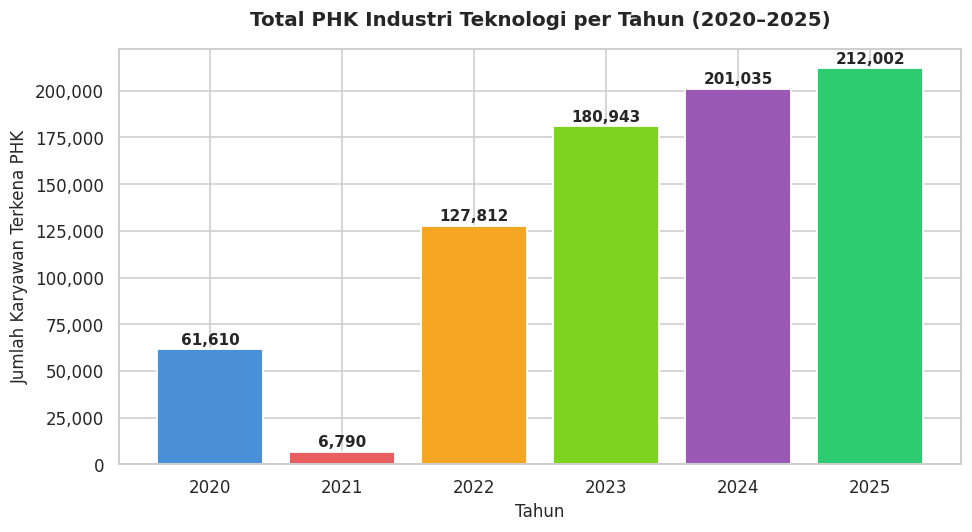

Gambar 1: Total PHK per Tahun


In [ ]:
# Hitung total PHK per tahun
layoffs_per_year = df_clean.groupby('Year')['Laid_Off'].sum().reset_index()
layoffs_per_year.columns = ['Tahun', 'Total PHK']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(layoffs_per_year['Tahun'].astype(str),
               layoffs_per_year['Total PHK'],
               color=['#4A90D9','#E85D5D','#F5A623','#7ED321','#9B59B6','#2ECC71'],
               edgecolor='white', linewidth=1.2)

# Tambahkan label nilai di atas bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1000,
            f'{int(height):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Total PHK Industri Teknologi per Tahun (2020–2025)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Tahun', fontsize=11)
ax.set_ylabel('Jumlah Karyawan Terkena PHK', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('viz_tren_phk_per_tahun.png', bbox_inches='tight')
plt.show()
print('Gambar 1: Total PHK per Tahun')

### 5.2 Tren Bulanan PHK (Line Chart)

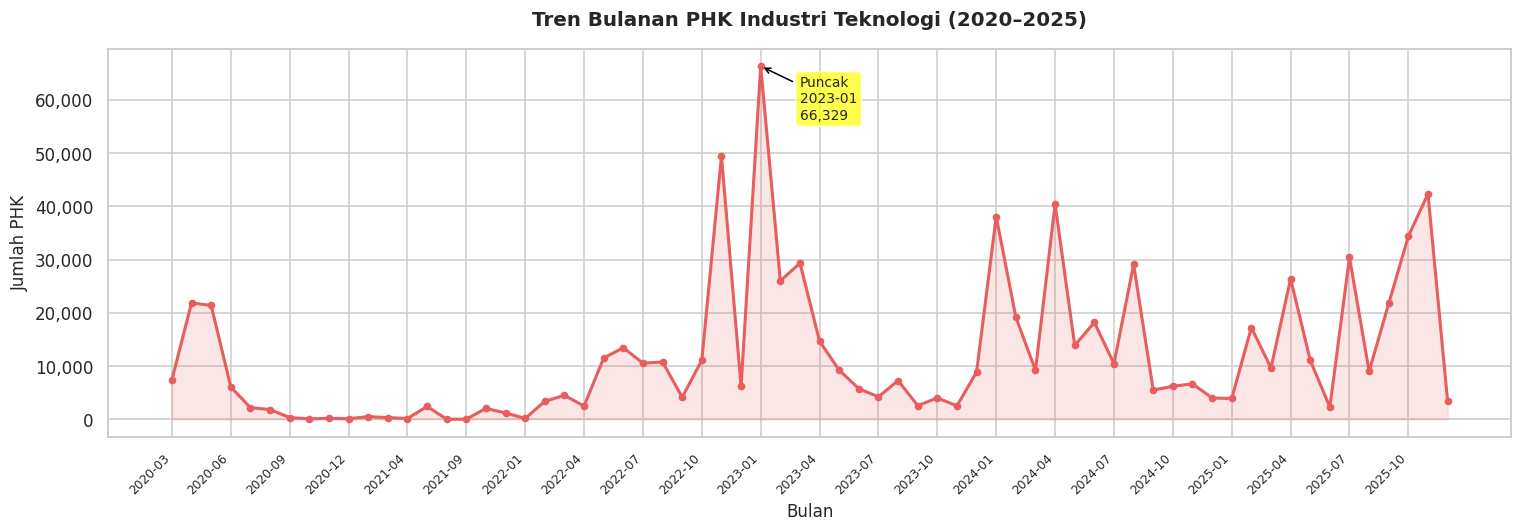

Gambar 2: Tren Bulanan PHK


In [ ]:
# Hitung PHK per bulan
monthly = df_clean.groupby('YearMonth')['Laid_Off'].sum().reset_index()
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['YearMonth_str'], monthly['Laid_Off'],
        color='#E85D5D', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly['YearMonth_str'], monthly['Laid_Off'],
                alpha=0.15, color='#E85D5D')

# Tandai puncak tertinggi
peak_idx = monthly['Laid_Off'].idxmax()
ax.annotate(f"Puncak\n{monthly.loc[peak_idx,'YearMonth_str']}\n{int(monthly.loc[peak_idx,'Laid_Off']):,}",
            xy=(peak_idx, monthly.loc[peak_idx,'Laid_Off']),
            xytext=(peak_idx + 2, monthly.loc[peak_idx,'Laid_Off'] * 0.85),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_title('Tren Bulanan PHK Industri Teknologi (2020–2025)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('Jumlah PHK', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Kurangi label sumbu X supaya tidak penuh
tick_step = max(1, len(monthly) // 18)
ax.set_xticks(ax.get_xticks()[::tick_step])
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('viz_tren_bulanan.png', bbox_inches='tight')
plt.show()
print('Gambar 2: Tren Bulanan PHK')

### 5.3 Top 10 Perusahaan dengan PHK Terbanyak

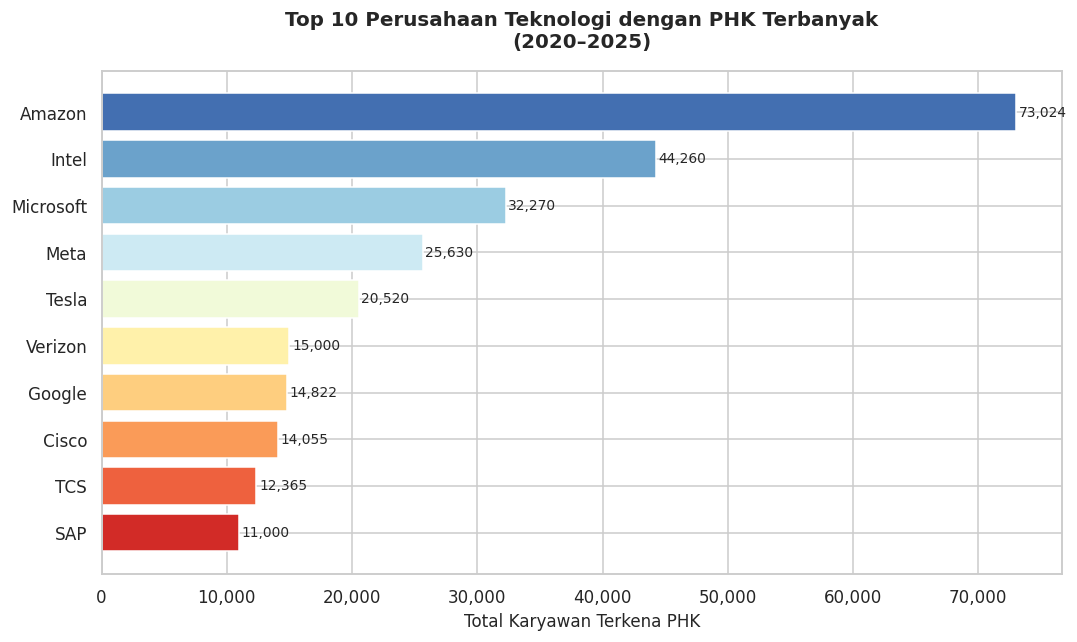

Gambar 3: Top 10 Perusahaan


In [ ]:
# Aggregasi PHK per perusahaan
top_companies = (df_clean.groupby('Company')['Laid_Off']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index())
top_companies.columns = ['Perusahaan', 'Total PHK']

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('RdYlBu_r', len(top_companies))
bars = ax.barh(top_companies['Perusahaan'], top_companies['Total PHK'],
                color=palette, edgecolor='white')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 200, bar.get_y() + bar.get_height()/2,
            f'{int(width):,}', va='center', fontsize=9)

ax.set_title('Top 10 Perusahaan Teknologi dengan PHK Terbanyak\n(2020–2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Total Karyawan Terkena PHK', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz_top10_company.png', bbox_inches='tight')
plt.show()
print('Gambar 3: Top 10 Perusahaan')

### 5.4 Distribusi PHK per Industri

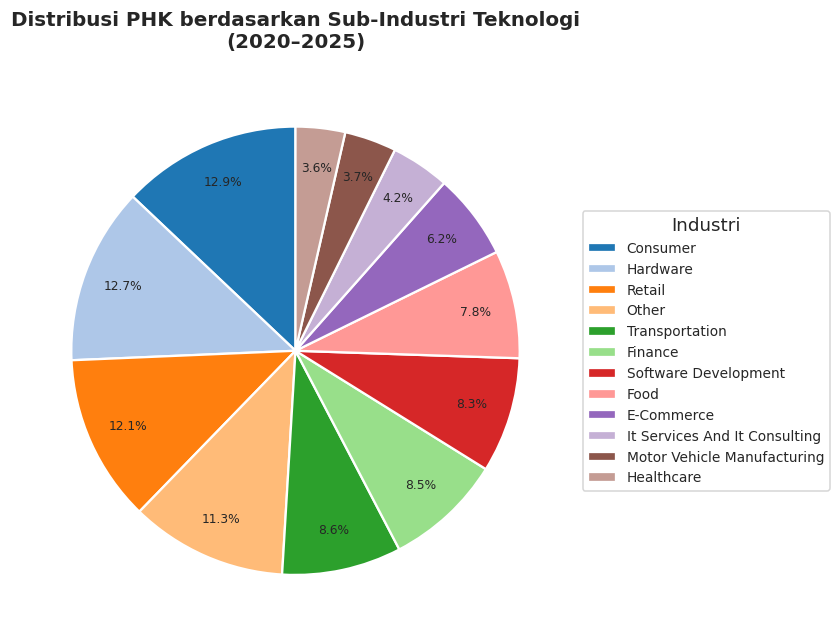

Gambar 4: Distribusi PHK per Industri


In [ ]:
# PHK per industri (top 12)
industry_layoffs = (df_clean.groupby('Industry')['Laid_Off']
                     .sum()
                     .sort_values(ascending=False)
                     .head(12)
                     .reset_index())
industry_layoffs.columns = ['Industri', 'Total PHK']

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('tab20', len(industry_layoffs))
wedges, texts, autotexts = ax.pie(
    industry_layoffs['Total PHK'],
    labels=None,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for autotext in autotexts:
    autotext.set_fontsize(8)

ax.legend(wedges, industry_layoffs['Industri'],
          title='Industri', loc='center left',
          bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)
ax.set_title('Distribusi PHK berdasarkan Sub-Industri Teknologi\n(2020–2025)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('viz_distribusi_industri.png', bbox_inches='tight')
plt.show()
print('Gambar 4: Distribusi PHK per Industri')

### 5.5 Top 10 Negara dengan PHK Terbanyak

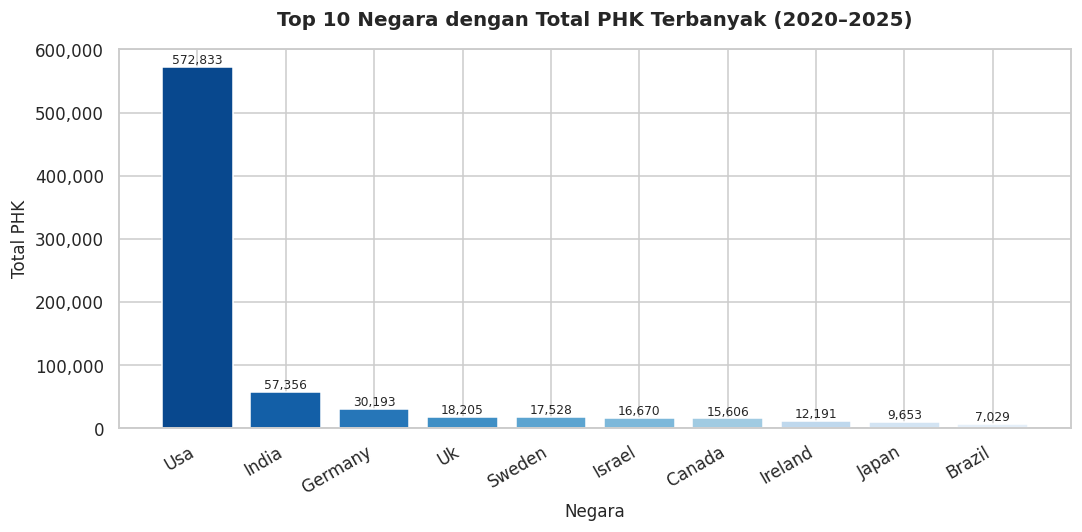

Gambar 5: Top 10 Negara


In [ ]:
# PHK per negara
country_layoffs = (df_clean.groupby('Country')['Laid_Off']
                    .sum()
                    .sort_values(ascending=False)
                    .head(10)
                    .reset_index())
country_layoffs.columns = ['Negara', 'Total PHK']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(country_layoffs['Negara'], country_layoffs['Total PHK'],
               color=sns.color_palette('Blues_r', len(country_layoffs)),
               edgecolor='white')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 500,
            f'{int(height):,}', ha='center', va='bottom', fontsize=8)

ax.set_title('Top 10 Negara dengan Total PHK Terbanyak (2020–2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Negara', fontsize=11)
ax.set_ylabel('Total PHK', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('viz_top10_negara.png', bbox_inches='tight')
plt.show()
print('Gambar 5: Top 10 Negara')

### 5.6 Distribusi PHK berdasarkan Stage Perusahaan

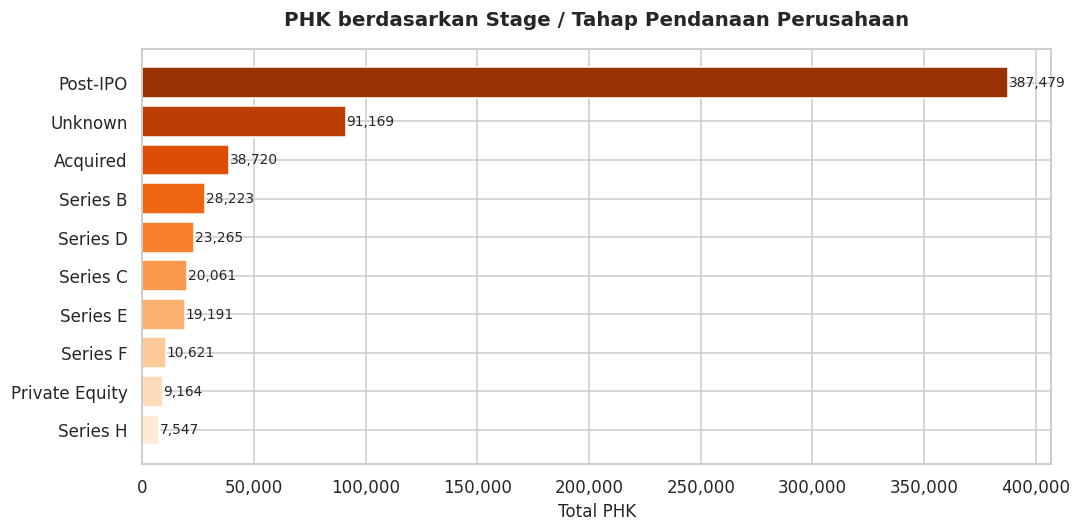

Gambar 6: PHK per Stage Perusahaan


In [ ]:
# PHK berdasarkan stage / tahap pendanaan perusahaan
stage_layoffs = (df_clean.groupby('Stage')['Laid_Off']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index())
stage_layoffs.columns = ['Stage', 'Total PHK']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(stage_layoffs['Stage'], stage_layoffs['Total PHK'],
                color=sns.color_palette('Oranges_r', len(stage_layoffs)),
                edgecolor='white')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 300, bar.get_y() + bar.get_height()/2,
            f'{int(width):,}', va='center', fontsize=9)

ax.set_title('PHK berdasarkan Stage / Tahap Pendanaan Perusahaan',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Total PHK', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz_stage.png', bbox_inches='tight')
plt.show()
print('Gambar 6: PHK per Stage Perusahaan')

### 5.7 Heatmap PHK per Tahun dan Industri

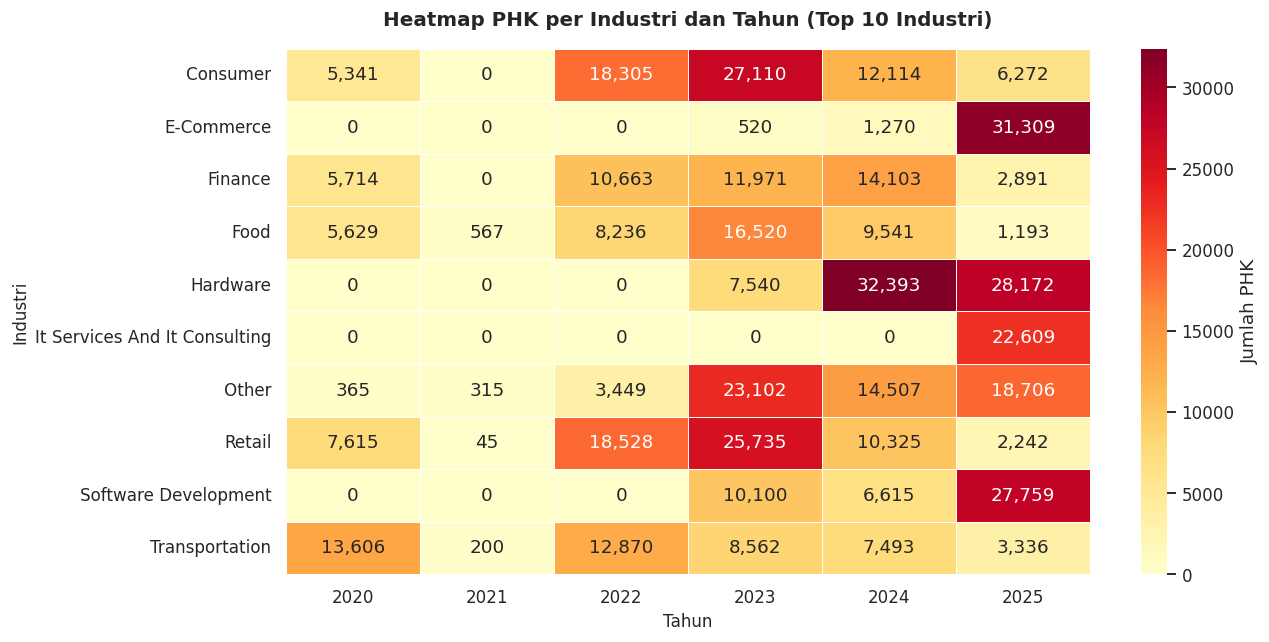

Gambar 7: Heatmap PHK per Industri dan Tahun


In [ ]:
# Pivot: baris = industri, kolom = tahun
top_industries = (df_clean.groupby('Industry')['Laid_Off']
                   .sum()
                   .sort_values(ascending=False)
                   .head(10)
                   .index.tolist())

# Mengambil data top 10 industri
heatmap_data = (df_clean[df_clean['Industry'].isin(top_industries)]
                .groupby(['Industry', 'Year'])['Laid_Off']
                .sum()
                .unstack(fill_value=0))

# Mengubah Tipe Data Menjadi Integer Untuk Mencegah Error Format
heatmap_data = heatmap_data.fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heatmap_data,
            annot=True, fmt=',d',
            cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'Jumlah PHK'})
ax.set_title('Heatmap PHK per Industri dan Tahun (Top 10 Industri)',
            fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Tahun', fontsize=11)
ax.set_ylabel('Industri', fontsize=11)
plt.tight_layout()
plt.savefig('viz_heatmap_industri.png', bbox_inches='tight')
plt.show()
print('Gambar 7: Heatmap PHK per Industri dan Tahun')

### 5.8 Distribusi Persentase PHK (Boxplot)

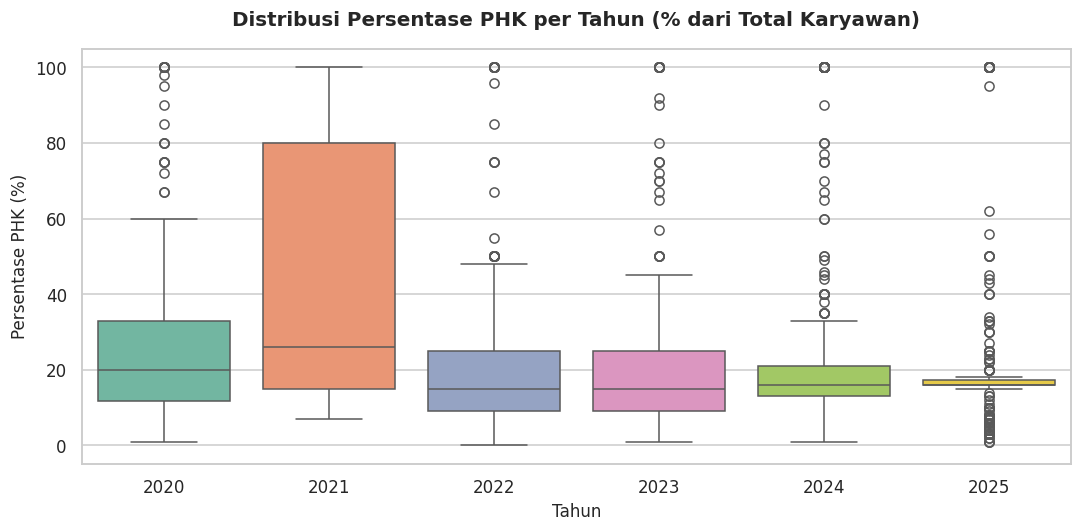

Gambar 8: Distribusi Persentase PHK per Tahun


In [ ]:
# Distribusi persentase PHK terhadap total karyawan, per tahun
fig, ax = plt.subplots(figsize=(10, 5))
year_order = sorted(df_clean['Year'].dropna().unique().astype(int))

sns.boxplot(data=df_clean,
            x='Year',
            y='Percentage',
            order=year_order,
            palette='Set2',
            ax=ax)

ax.set_title('Distribusi Persentase PHK per Tahun (% dari Total Karyawan)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Tahun', fontsize=11)
ax.set_ylabel('Persentase PHK (%)', fontsize=11)
plt.tight_layout()
plt.savefig('viz_boxplot_pct.png', bbox_inches='tight')
plt.show()
print('Gambar 8: Distribusi Persentase PHK per Tahun')

## 6. Ringkasan Hasil Analisis

In [ ]:
print('=' * 60)
print('RINGKASAN ANALISIS PHK INDUSTRI TEKNOLOGI 2020-2025')
print('=' * 60)

print(f'\nTotal records           : {len(df_clean):,}')
print(f'Total perusahaan unik   : {df_clean["Company"].nunique():,}')
print(f'Total karyawan terkena PHK: {df_clean["Laid_Off"].sum():,.0f}')
print(f'Rata-rata PHK per event : {df_clean["Laid_Off"].mean():,.0f}')
print(f'Median persentase PHK   : {df_clean["Percentage"].median():.1f}%')

print(f'\nTahun PHK terbanyak     : {int(layoffs_per_year.loc[layoffs_per_year["Total PHK"].idxmax(), "Tahun"])}')
print(f'Perusahaan PHK terbanyak: {top_companies.iloc[0]["Perusahaan"]} ({int(top_companies.iloc[0]["Total PHK"]):,})')
print(f'Industri PHK terbanyak  : {industry_layoffs.iloc[0]["Industri"]} ({int(industry_layoffs.iloc[0]["Total PHK"]):,})')
print(f'Negara PHK terbanyak    : {country_layoffs.iloc[0]["Negara"]} ({int(country_layoffs.iloc[0]["Total PHK"]):,})')
print('=' * 60)

RINGKASAN ANALISIS PHK INDUSTRI TEKNOLOGI 2020-2025

Total records           : 2,412
Total perusahaan unik   : 1,713
Total karyawan terkena PHK: 790,193
Rata-rata PHK per event : 331
Median persentase PHK   : 16.0%

Tahun PHK terbanyak     : 2025
Perusahaan PHK terbanyak: Amazon (73,024)
Industri PHK terbanyak  : Consumer (69,142)
Negara PHK terbanyak    : Usa (572,833)
